In [10]:
# Health Insurance

In [2]:
import pandas as pd
import joblib
from lightgbm import LGBMRegressor
from sklearn.preprocessing import LabelEncoder

In [4]:
df = pd.read_csv("Data/insurance.csv")

In [5]:
# BMI Kategorileri
df.loc[df['bmi'] < 18.5, 'BMI_CAT'] = 'underweight'
df.loc[(df['bmi'] >= 18.5) & (df['bmi'] < 25), 'BMI_CAT'] = 'ideal'
df.loc[(df['bmi'] >= 25) & (df['bmi'] < 30), 'BMI_CAT'] = 'overweight'
df.loc[df['bmi'] >= 30, 'BMI_CAT'] = 'obese'

# Yaş Grupları
df.loc[(df["age"] <= 35), "AGE_CAT"] = "young"
df.loc[(df["age"] > 35) & (df["age"] <= 55), "AGE_CAT"] = "middle"
df.loc[(df["age"] > 55), "AGE_CAT"] = "old"

# Etkileşim: Sigara ve BMI (En önemli belirteçlerden biri)
df.loc[(df["smoker"] == "yes") & (df["bmi"] >= 30), "is_smoker_obese"] = 1
df.fillna({"is_smoker_obese": 0}, inplace=True)

In [6]:
# Encode İşlemleri
binary_cols = ['sex', 'smoker']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [7]:
# Encode İşlemleri
binary_cols = ['sex', 'smoker']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=['region', 'BMI_CAT', 'AGE_CAT'], drop_first=True)

In [8]:
X = df.drop("charges", axis=1)
y = df["charges"]

# Model Eğitimi
model = LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1)
model.fit(X, y)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [9]:
# Dosyaları Kaydet
joblib.dump(model, "lgbm_model.pkl")
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

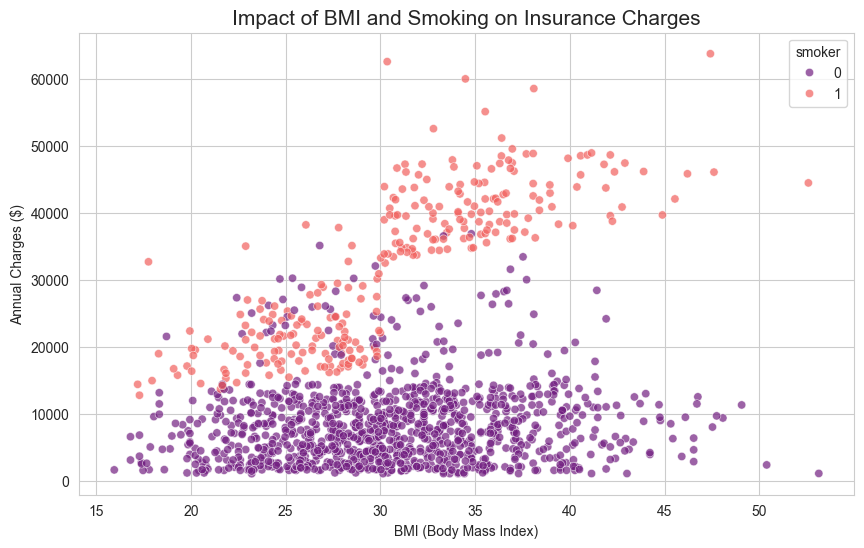

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Sigara ve BMI etkileşiminin Charges üzerindeki etkisi
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", palette="magma", alpha=0.7)
plt.title("Impact of BMI and Smoking on Insurance Charges", fontsize=15)
plt.xlabel("BMI (Body Mass Index)")
plt.ylabel("Annual Charges ($)")
plt.show()

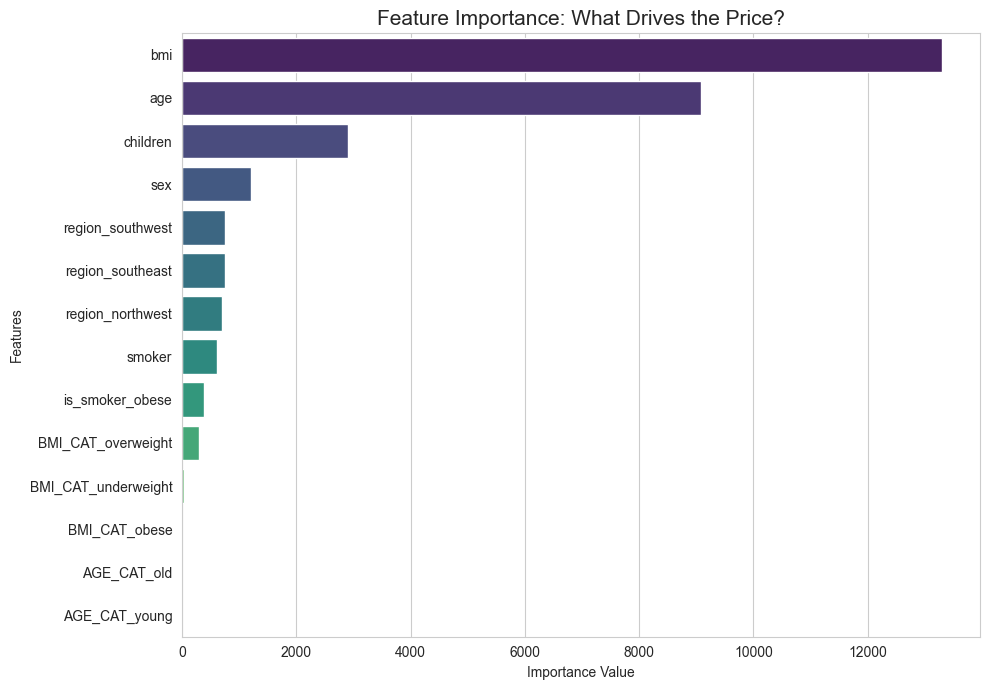

In [13]:
feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': X.columns})

plt.figure(figsize=(10, 7))
# hue="Feature" ekleyerek uyarıyı gideriyoruz
sns.barplot(x="Value", 
            y="Feature", 
            data=feature_imp.sort_values(by="Value", ascending=False), 
            palette="viridis", 
            hue="Feature", 
            legend=False)

plt.title('Feature Importance: What Drives the Price?', fontsize=15)
plt.xlabel("Importance Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()